In [84]:
from pyspark.sql import SparkSession as ss
import pyspark.sql.functions as func
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator as bce

from pyspark.sql.types import StructType
from pyspark.sql.types import StructField 
from pyspark.sql.types import StringType
from pyspark.sql.types import IntegerType

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

*******************************Section 1*******************************

In [6]:
spark = ss.builder.appName("QUalifBDP_2").getOrCreate()

In [10]:
dfSpark = spark.read.csv("births.csv", header=True, inferSchema=True)

In [16]:
pdf = dfSpark.toPandas()
pdf.head()

,INFANT_ALIVE_AT_REPORT,BIRTH_YEAR,BIRTH_MONTH,BIRTH_PLACE,MOTHER_AGE_YEARS,MOTHER_RACE_6CODE,MOTHER_EDUCATION,FATHER_COMBINED_AGE,FATHER_EDUCATION,MONTH_PRECARE_RECODE,...,INFANT_ANTIBIOTICS,INFANT_SEIZURES,INFANT_NO_ABNORMALITIES,INFANT_ANCEPHALY,INFANT_MENINGOMYELOCELE,INFANT_LIMB_REDUCTION,INFANT_DOWN_SYNDROME,INFANT_SUSPECTED_CHROMOSOMAL_DISORDER,INFANT_NO_CONGENITAL_ANOMALIES_CHECKED,INFANT_BREASTFED
0,N,2015,2,1,29,3,9,99,9,4,...,N,N,0,N,N,N,N,N,0,N
1,N,2015,2,1,22,1,3,29,4,1,...,N,N,0,N,N,N,N,C,0,N
2,N,2015,2,1,38,1,4,40,3,1,...,U,U,9,N,N,N,N,N,1,N
3,N,2015,4,1,39,2,7,42,6,1,...,N,Y,0,Y,N,N,N,N,0,N
4,N,2015,4,1,18,3,2,99,9,2,...,U,U,9,N,N,N,N,N,1,N


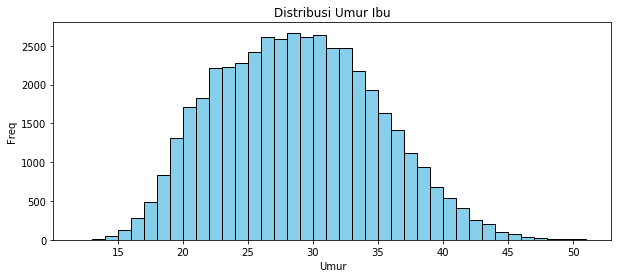

In [21]:
plt.figure(figsize=(10,4))
plt.hist(pdf['MOTHER_AGE_YEARS'], 
         bins=range(min(pdf['MOTHER_AGE_YEARS']), max(pdf['MOTHER_AGE_YEARS'])+2), 
         edgecolor='black', color='skyblue')
plt.title("Distribusi Umur Ibu")
plt.xlabel("Umur")
plt.ylabel("Freq")
plt.show()

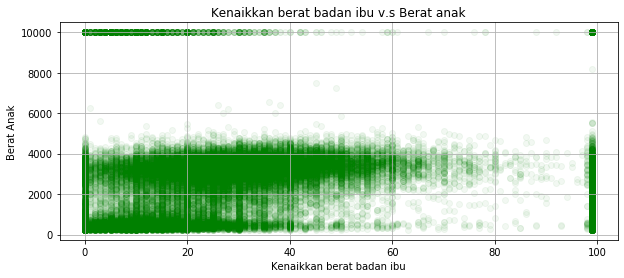

In [33]:
plt.figure(figsize=(10,4))
plt.scatter(pdf['MOTHER_WEIGHT_GAIN'], pdf['INFANT_WEIGHT_GRAMS'], color='green', alpha=0.05)
plt.title("Kenaikkan berat badan ibu v.s Berat anak")
plt.xlabel("Kenaikkan berat badan ibu")
plt.ylabel("Berat Anak")
plt.grid(True)
plt.show()

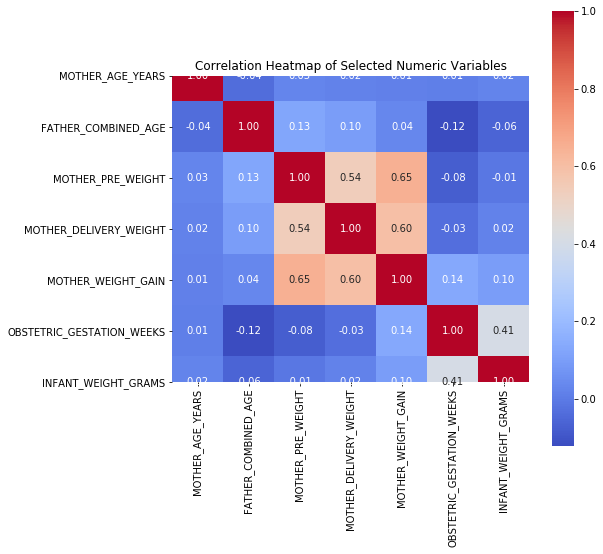

In [32]:
# Select a subset of numeric columns for the heatmap
cols = ['MOTHER_AGE_YEARS', 'FATHER_COMBINED_AGE', 'MOTHER_PRE_WEIGHT', 
        'MOTHER_DELIVERY_WEIGHT', 'MOTHER_WEIGHT_GAIN', 
        'OBSTETRIC_GESTATION_WEEKS', 'INFANT_WEIGHT_GRAMS']
        
data_subset = pdf[cols]

plt.figure(figsize=(8,8))
corr_matrix = data_subset.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Korelasi dari beberapa row")
plt.show()

*******************************Section 2*******************************

In [39]:
#Nomor 1
spark2 = ss.builder.appName("PrediksiKeselamatanAnak").getOrCreate()
df = spark.read.csv("births.csv", header=True, inferSchema=True)
df = df.withColumn("label", func.when(func.col("INFANT_ALIVE_AT_REPORT") == "Y", 1).otherwise(0))

df.show(5)

+----------------------+----------+-----------+-----------+----------------+-----------------+----------------+-------------------+----------------+--------------------+----------+---------+---------+---------+----------------+-----------------+-----------------+----------------------+------------------+------------+-------------+------------+-------------+------------------+-------+----------------------+---------+----------+--------+-----------+----------+------------------------+---------------+-------+--------------+--------+---------------+----------+-------------------------+-------------------+-------------------+------------------------+---------------------+----------------+------------------+---------------+-----------------------+----------------+-----------------------+---------------------+--------------------+-------------------------------------+--------------------------------------+----------------+-----+
|INFANT_ALIVE_AT_REPORT|BIRTH_YEAR|BIRTH_MONTH|BIRTH_PLACE|MOTHE

In [40]:
#Nomor 2
df = df.na.drop()

In [65]:
#nomor 3
feature = [
    "BIRTH_YEAR",
    "BIRTH_MONTH",
    "MOTHER_AGE_YEARS",
    "MOTHER_EDUCATION",
    "FATHER_COMBINED_AGE",
    "MOTHER_PRE_WEIGHT",
    "MOTHER_DELIVERY_WEIGHT",
    "MOTHER_WEIGHT_GAIN"
]

In [82]:
#nomor 4&5
assembler = VectorAssembler(inputCols=feature, outputCol="assembled_features")
scaler = StandardScaler(inputCol="assembled_features", outputCol="scaledFeatures")
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label")
pipeline = Pipeline(stages=[assembler, scaler, lr])
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_data)

In [85]:
predictions = model.transform(test_data)

predictions.select("label", "prediction", "probability").show(5)

evaluator = bce(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print("Test Area Under ROC: {:.2f}".format(auc))

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       1.0|[0.48662053513938...|
|    0|       1.0|[0.48572464443053...|
|    0|       1.0|[0.48549170222144...|
|    0|       1.0|[0.48599601783559...|
|    0|       1.0|[0.48711298828757...|
+-----+----------+--------------------+
only showing top 5 rows

Test Area Under ROC: 0.69
